In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from xgboost.sklearn import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from scipy.special import entr
from sklearn import preprocessing
import matplotlib.pyplot as plt
import math
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from IPython.display import display
#import itertools
#from itables import init_notebook_mode
import random
#init_notebook_mode(all_interactive=True)


In [8]:
os.chdir('./datasets')
arr = os.listdir()
files_dict = {}


for i in arr:
    #print(i)
    print(i)
    if i == ".DS_Store":
        continue
    os.chdir(i)

    arr2 = os.listdir()
    print(len(arr2))

    if len(arr2) != 0:

        print(arr2)
        w = './training'
        os.chdir(w)
        arr3 = os.listdir()


        files_dict[i] = arr3
        

        os.chdir('../')

    os.chdir('../')
    print(os.listdir())


os.chdir('../')


1
1
['training']
['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '3', '4', '5', '6', '7', '8', '9']
10
1
['training']
['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '3', '4', '5', '6', '7', '8', '9']
11
1
['training']
['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '3', '4', '5', '6', '7', '8', '9']
12
1
['training']
['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '3', '4', '5', '6', '7', '8', '9']
13
1
['training']
['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '3', '4', '5', '6', '7', '8', '9']
14
1
['training']
['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '3', '4', '5', '6', '7', '8', '9']
15
1
['training']
['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '3', '4', '5', '6', '7', '8', '9']
16
1
['training']
['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '3', '4', '5', '6', '7', '8', '9']
17
1
['tr

In [5]:
# Print first element of files_dict with keys and values
print(files_dict['1'])

['session_122839150245.csv', 'session_231028282710.csv', 'session_296616657157.csv', 'session_320846578851.csv', 'session_359840453196.csv', 'session_411580470436.csv', 'session_515566219016.csv', 'session_632092628639.csv', 'session_925043071260.csv', 'session_956704593939.csv']


In [10]:
# Take the first three elements of files_dict and print them
print(list(files_dict.keys())[:3])
# Store the printed elements in a list with keys and associated values
keys = list(files_dict.keys())[:3]
values = list(files_dict.values())[:3]
# Create a new dictionaries from these lists
new_dict_2 = dict(zip(keys, values))
print(new_dict_2)
#files_dict.keys()

['1', '10', '11']
{'1': ['session_122839150245.csv', 'session_231028282710.csv', 'session_296616657157.csv', 'session_320846578851.csv', 'session_359840453196.csv', 'session_411580470436.csv', 'session_515566219016.csv', 'session_632092628639.csv', 'session_925043071260.csv', 'session_956704593939.csv'], '10': ['session_143795894305.csv', 'session_165182884399.csv', 'session_37010613109.csv', 'session_678584946341.csv', 'session_75048677177.csv', 'session_815559789639.csv', 'session_836326465893.csv', 'session_838251991518.csv', 'session_848510543322.csv', 'session_891882207685.csv'], '11': ['session_192435781543.csv', 'session_263295640992.csv', 'session_326144459225.csv', 'session_348266869825.csv', 'session_502369252757.csv', 'session_835059643683.csv', 'session_840446959017.csv', 'session_863065563839.csv', 'session_961938096102.csv', 'session_998599678338.csv']}


In [12]:
user_dict = {}
user_dict_by_category = {}
all_category = ['office\n', 'file system\n', 'browsing\n', 'gaming\n', 'entertainment\n', 'development\n']



for i in list(new_dict_2.keys()):
    user_dict[i] = []
    user_dict_by_category[i] = {}
    for category in all_category:
        user_dict_by_category[i][category] = []

    #count = 1
    for j in list(files_dict[i]):

        #user_dict[i][count] = None
        w = './datasets/' + i + '/training/' + j
        file1 = open(w, 'r')
        Lines = file1.readlines()
        txt_array = []
        for k in range(0, len(Lines)):
            #print(Lines[k].split(","))
            txt_array.append(Lines[k].split(","))

        tmpp = pd.DataFrame(txt_array[1:], columns=txt_array[0])
        tmpp['timestamp'] = [int(i[0])*1000 + int(str(i[1])[:3].ljust(3, '0')) for i in tmpp['client_timestamp'].str.split('.')]
        uniquess = tmpp['window\n'].unique().tolist()
        #        print(uniquess)
        tmpp = tmpp[tmpp['window\n'] == 'browsing\n']
        user_dict[i].append(tmpp)
        for k in all_category:
            tmpp = tmpp[tmpp['window\n'] == k]
            #tmpp = tmpp[tmpp['state'] == "Move"]
            if tmpp.empty:
                user_dict_by_category[i][k].append(tmpp)


In [23]:
capital_city = {"Nepal": "Kathmandu", "Italy": "Rome", "England": "London"}
list(capital_city.keys())

TypeError: 'DataFrame' object is not callable

In [ ]:
new_dict = {key: user_dict[key] for key in ['1', '2']}

print(new_dict)

{'1': [          client_timestamp     x    y button state    window\n      timestamp
0           1570079547.403  1268  597   None  Move  browsing\n  1570079547403
1           1570079547.447  1348  616   None  Move  browsing\n  1570079547447
2           1570079547.482  1474  649   None  Move  browsing\n  1570079547482
3       1570079547.4970002  1550  666   None  Move  browsing\n  1570079547497
4       1570079547.5029998  1579  671   None  Move  browsing\n  1570079547502
...                    ...   ...  ...    ...   ...         ...            ...
160447      1570131451.629   685  506   None  Move  browsing\n  1570131451629
160448      1570131451.641   685  505   None  Move  browsing\n  1570131451641
160449      1570131451.653   685  504   None  Move  browsing\n  1570131451653
160450      1570131451.665   686  503   None  Move  browsing\n  1570131451665
160451      1570131451.677   687  501   None  Move  browsing\n  1570131451677

[159639 rows x 7 columns],           client_timestamp   

In [15]:
import pandas as pd
# extract the desired keys and rows from data_dict
new_data_dict = {key: [df[["state", "x", "y", "timestamp"]] for df in df_list] for key, df_list in user_dict.items() if "1" in key or "2" in key}

In [1]:


list(new_data_dict.keys())

NameError: name 'new_data_dict' is not defined

In [16]:
latest_dict_1 = {}
for key in (new_data_dict.keys()):
    # Print the currrent key and the length of the list of dataframes
    # To make them understable also print same statements using english words
    print("Current key: ", key)
    print("Length of list of dataframes: ", len(new_data_dict[key]))   
    
    # Use a seperator to make the output more readable
    print("--------------------------------------------------")
    # Create a new dictionary with the current key
    latest_dict_1[key] = {}
    latest_dict_1[key]['Move'] = []
    latest_dict_1[key]['Single_Click'] = []
    latest_dict_1[key]['Double_Click'] = []
    for df in new_data_dict[key]:
        tt = df[df['state'] != "Move"]
        a = [d for _, d in tt.groupby(tt.index - np.arange(len(tt)))]
        move = df[df['state'] == "Move"]
        move_list = [d for _, d in move.groupby(move.index - np.arange(len(move)))]
        for k in a:
            if len(k) == 2:
                latest_dict_1[key]['Single_Click'].append(k)
            if len(k) == 4:
                latest_dict_1[key]['Double_Click'].append(k)
        for y in move_list:
            latest_dict_1[key]['Move'].append(y)


Current key:  1
Length of list of dataframes:  10
--------------------------------------------------
Current key:  10
Length of list of dataframes:  10
--------------------------------------------------
Current key:  11
Length of list of dataframes:  10
--------------------------------------------------


In [18]:
def split_df(df, threshold):
    # Initialize an empty list to store the split dataframes
    dfs = []

    # Initialize an empty list to store the current segment of the dataframe
    segment = []

    # Iterate through the rows of the dataframe
    for i, row in df.iterrows():
        # If the current value in column X is less than or equal to the threshold, add the row to the current segment
        tmp = row['timestamp_diff']
        if tmp <= threshold:
            segment.append(row)
        # If the current value in column X is greater than the threshold, add the current segment to the list of split dataframes
        # and start a new segment with the current row
        else:
            if segment:
                dfs.append(pd.DataFrame(segment))
            segment = [row]

    # Add the last segment to the list of split dataframes
    if segment:
        dfs.append(pd.DataFrame(segment))

    # If no segments were found, return the original dataframe
    if not dfs:
        dfs.append(df)

    # Return the list of split dataframes
    return dfs

def timestamp_difference(df):
    max_index = df["timestamp"].idxmax()
    min_index = df["timestamp"].idxmin()
    max_timestamp = df["timestamp"].loc[max_index]
    min_timestamp = df["timestamp"].loc[min_index]
    return max_timestamp - min_timestamp

In [20]:
# create a sample dataframe
data = {'timestamp_diff': [1, 2, 3, 5, 8, 9, 3, 2, 12, 15]}
df = pd.DataFrame(data)

# call the split_df function
dfs = split_df(df, 5)

# print the list of split dataframes
for i, df in enumerate(dfs):
    print(f"DataFrame {i}:")
    print(df)
    print()

DataFrame 0:
   timestamp_diff
0               1
1               2
2               3
3               5

DataFrame 1:
   timestamp_diff
4               8

DataFrame 2:
   timestamp_diff
5               9
6               3
7               2

DataFrame 3:
   timestamp_diff
8              12

DataFrame 4:
   timestamp_diff
9              15



In [ ]:
latest_dict_1['1']['Move'][0]

,state,x,y,timestamp,timestamp_diff
0,Move,694,489,1570169899971,NaN
1,Move,703,473,1570169899990,0.019
2,Move,713,454,1570169900008,0.018
3,Move,725,436,1570169900028,0.020
4,Move,737,417,1570169900046,0.018
...,...,...,...,...,...
84,Move,519,53,1570169901296,0.008
85,Move,518,53,1570169901302,0.006
86,Move,518,54,1570169901310,0.008
87,Move,518,54,1570169901322,0.012


In [22]:
Movement_Dictionary = {}
for yt in new_data_dict.keys():
    Movement_Dictionary[yt] = []
    for curr in latest_dict_1[yt]['Move']:#[45:46]:
        if True:#len(curr) > 1000:
            threshold = 0.05
            #print(latest_dict_1['1']['Move'].index)
            #print(curr["timestamp"])
            maximum_index = curr["timestamp"].idxmax()
            minimum_index = curr["timestamp"].idxmin()
            maximum_timestamp = curr["timestamp"].loc[maximum_index]
            minimum_timestamp = curr["timestamp"].loc[minimum_index]
            curr['timestamp_diff'] = curr['timestamp'].diff() / 1000

            max_diff = curr['timestamp_diff'].max()
            min_diff = curr['timestamp_diff'].min()
            #print("Maximum timestamp difference", max_diff)
            #print("Minimum timestamp difference", min_diff)
            #print("Length of the list", len(curr['timestamp']))
            #print((maximum_timestamp - minimum_timestamp)/1000)
            # plt.plot(curr["timestamp_diff"])
            # plt.show()
            # plt.clf()
            count = 0
            for diff in curr["timestamp_diff"]:
                if diff > threshold:
                    count += 1
            #print("This is count", count)
            dfs = split_df(curr, threshold)
            #print("This is the len dfs", len(dfs))
            for yuyu in dfs:
                #print(yuyu)
                if True:#len(yuyu) > 100:


                    Movement_Dictionary[yt].append(yuyu)


                    yuyu['timestamp_diff_new'] = yuyu['timestamp'].diff() / 1000
                    #print(len(yuyu['timestamp_diff_new']))
                    # plt.plot(yuyu["timestamp_diff_new"])
                    # plt.show()
                    # plt.clf()
                    #print("Maximum timestmap", timestamp_difference(yuyu))
                    #print("Lenght of yuyu", len(yuyu))
                    #print("-000--")

            #print("--")

    # print max and min lengths of lists


    # Extract only the lists with more than 100 elements and less than 500 elements
    Movement_Dictionary[yt] = [lst for lst in Movement_Dictionary[yt] if 100 < len(lst) < 500]
    # Extract the reaming lists as a seperate temporary variable
    temp = [lst for lst in Movement_Dictionary[yt] if len(lst) >= 500]
    # Divide the lists stored in temp into smaller lists each containing less than 500 elements
    temp = [split_df(lst, 500) for lst in temp]
    # Combine temp and Movement_Dictionary['1'] and restore it into Movement_Dictionary['1'] again
    Movement_Dictionary[yt] = Movement_Dictionary[yt] + temp


    lengths = [len(lst) for lst in Movement_Dictionary[yt]]
    print("Maximum length of lists:", max(lengths))
    print("Minimum length of lists:", min(lengths))
    #for i in Movement_Dictionary['1']:
        #print(len(i))
    #print("---")
    #print(len(Movement_Dictionary['1']))

Maximum length of lists: 498
Minimum length of lists: 101
Maximum length of lists: 440
Minimum length of lists: 101
Maximum length of lists: 460
Minimum length of lists: 101


In [ ]:
len(Movement_Dictionary['1'])

361

In [ ]:
# Calculate the speed of the mouse for the given list as argument
def Calculate_total_speed(list):
    # Calculate the distance between the first and last point in the list
    distance = math.sqrt((list["x"].iloc[-1] - list["x"].iloc[0])**2 + (list["y"].iloc[-1] - list["y"].iloc[0])**2)
    # Calculate the time difference between the first and last point in the list
    time = (list["timestamp"].iloc[-1] - list["timestamp"].iloc[0])/1000
    # Calculate the speed
    speed = distance/time
    return speed



# Calculate the speed of the mouse for the given list between consecutive points using diff function
# and returns the speeds as a list
def calculate_consecutive_speed(list):
    # Calculate the distance between consecutive points
    list["x"] = list["x"].astype(float)
    list["y"] = list["y"].astype(float)
    

    distance = np.sqrt((list["x"].diff())**2 + (list["y"].diff())**2)
    # Calculate the time difference between consecutive points
    time = list["timestamp_diff"]
    # Calculate the speed
    speed = distance/time
    #return speed
    return np.mean(speed)

In [ ]:
# Calculate speed for each list
# Create dictionary to store the speeds
speeds_dict = {}
features_array = []
for ty in new_data_dict.keys():
    speeds = []
    features = {}
    print("yt:", ty)
    
    for lst in Movement_Dictionary[ty]:
        features['user'] = ty
        # Calling calculate_consecutive_speed function
        speed = calculate_consecutive_speed(lst)
        # Append the speed list to the speeds list
        features['speed_mean'] = speed
        speeds.append(speed)
        # Plot the speed list
        features_array.append(features)
    
    speeds_dict[ty] = speeds
    print(len(speeds_dict[ty]))

df_train = pd.DataFrame(features_array)
df_train.dropna(inplace=True)
train = df_train.copy()
na_sum = train.isna().sum().sum()
which_na = train.isna().any()
which_inf = train.isin([np.inf, -np.inf]).any()

#print(na_sum)
#print(which_na)
#print(which_inf)




donottouch = train.copy()

train = donottouch.copy()


yt: 1
2679
yt: 10
2912
yt: 11
3666


c:\ProgramData\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
c:\ProgramData\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
c:\ProgramData\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-lev

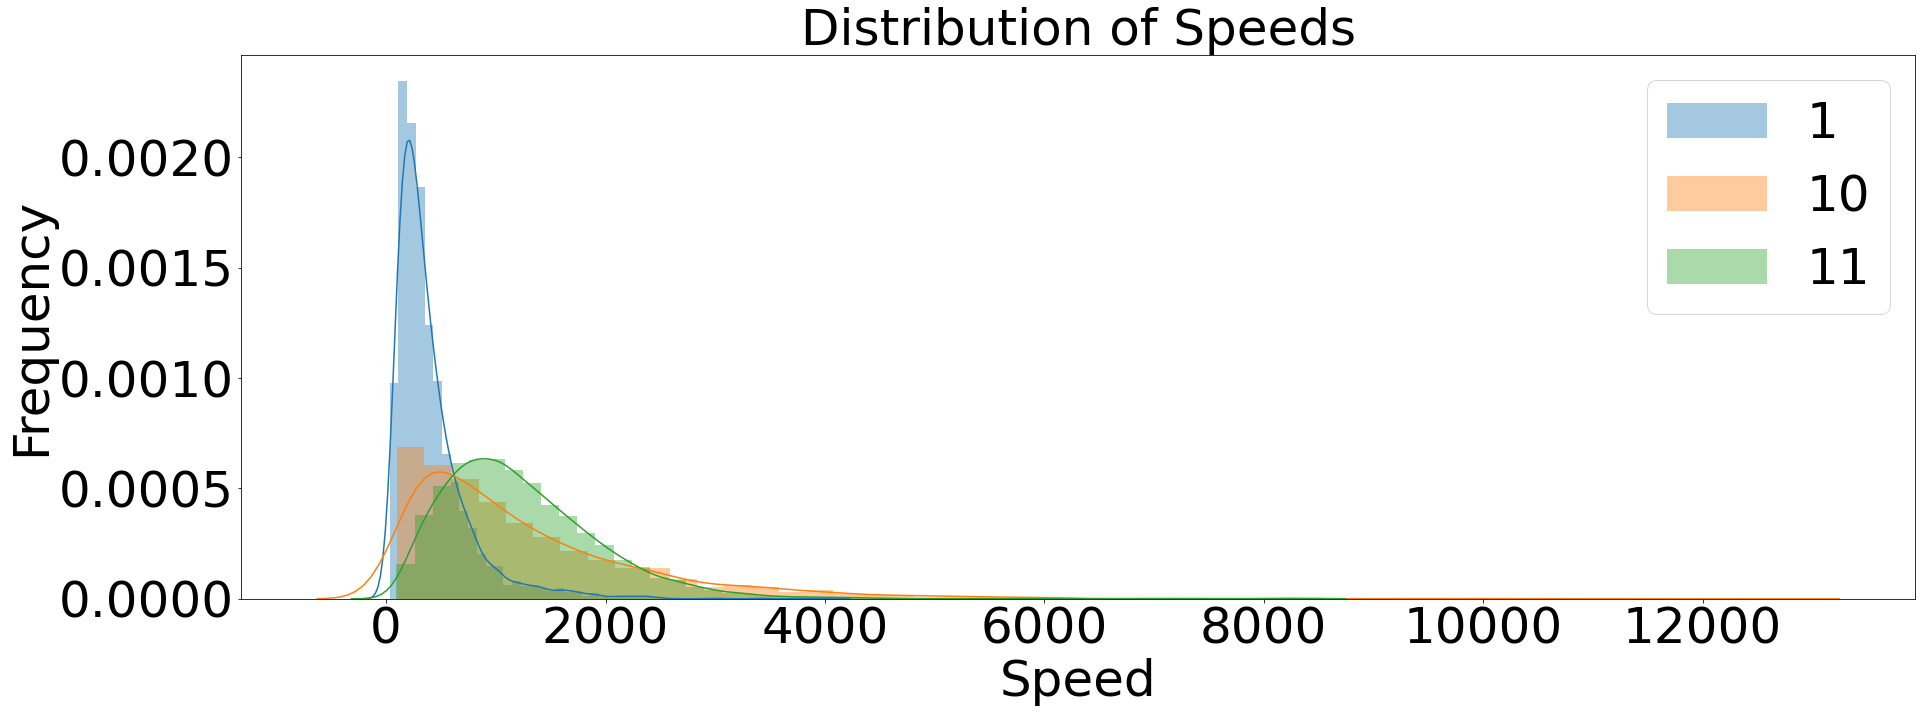

In [ ]:

# The function checks if the given list contains any inf values
def check_inf(list):
    for i in list:
        if i == np.inf or i == -np.inf:
            return True
    return False
# The function applies isomap dimensionality reduction to the given list
def isomap(list):
    # Create an isomap object
    iso = Isomap(n_components=2)
    # Fit the list to the isomap object
    iso.fit(list)
    # Transform the list using the isomap object
    manifold = iso.transform(list)
    return manifold


# Plotting the distribution of the speed
for i in (new_data_dict.keys()):
    # Checking if the list contains any inf values
    if check_inf(speeds_dict[i]):
        # If the list contains inf values, remove them
        speeds_dict[i] = [x for x in speeds_dict[i] if x != np.inf and x != -np.inf]
    # Apply isomap to the list
        #speeds_dict[i] = isomap(speeds_dict[i])    


    sns.distplot(speeds_dict[i], label=i)
# Make the legends visible and bigger
plt.legend(prop={'size': 50})
# Put labels to axes
plt.xlabel("Speed", fontsize=50)
plt.ylabel("Frequency", fontsize=50)
# Set the size of the figure
#plt.figure(figsize=(100, 100))
# Set the size of the ticks
plt.xticks(fontsize=50)
plt.yticks(fontsize=50)
# Set the size of the labels
plt.title("Distribution of Speeds", fontsize=50)
# Show the plot


plt.show()



In [ ]:
print(speeds_dict['1'])

[64.56147864655101, 313.1279647308414, 343.1459795727568, 320.51090623055734, 122.49010800939891, 596.6055485288289, 473.0224961010405, 336.73742467981936, 144.49167377282814, 174.51060353915895, 297.06425636034777, 141.88489837944502, 55.9921551795016, 218.5006529429503, 670.2836819102818, 331.29813037611314, 293.6352803571789, 213.7254715857257, 316.7020777801338, 408.1197753060159, 205.57709031707375, 224.16521775764002, 156.3900168706295, 65.5404632792556, 966.4790319764362, 300.5785620993311, 380.3630583868656, 148.33729859424287, 177.05356430679186, 213.12444483472188, 144.3838922300581, 359.51159414025017, 289.0266597252399, 261.473580434884, 747.8848259575577, 321.86715847852787, 149.76570094962605, 247.8032206351978, 456.1625191961954, 170.25401670094683, 122.3229947234903, 266.05008412209, 308.31105459537986, 479.79501835227626, 608.2063954264515, 382.52486478901835, 771.2153478623754, 299.9282239109458, 223.36509638242933, 429.25032423778, 761.898032436933, 587.3791543882364

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from xgboost.sklearn import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from scipy.special import entr
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler

total_array = []

features_array = []
test = []
total_0 = 0
diff = 0

all_acc_mean = []
mouse_result_dataframe_total = pd.DataFrame()
for i in (new_data_dict.keys())[:2]:
    mouse_result_dataframe = pd.DataFrame()
    train = donottouch.copy()

    # train["user"] = train_tmp["user"]
    print("----")
    print(i)
    this_user = train[train["user"] == i]

    not_this_user = train[train["user"] != i]
    not_this_user = shuffle(not_this_user, random_state=20)[:len(this_user)]
    # print("This is attackers")
    # print(not_this_user)
    # print("----")
    train = pd.concat([this_user, not_this_user])



    # X_new1 = train.copy()                                        # Create duplicate of data
    # X_new1.replace([np.inf, - np.inf], np.nan, inplace = True)
    # train=X_new1.dropna()



    train.loc[train["user"] != i, "user"] = "Attacker"



    Y =  train.loc[:,'user']
    Y = (Y == "Attacker").astype(int)


    X = train.loc[:, train.columns != 'user']



    scaler = StandardScaler()

    X = scaler.fit_transform(X)


    X = preprocessing.normalize(X)


    x_train,x_val,y_train,y_val = train_test_split(X,Y, test_size = 0.3, random_state=40)#, stratify=Y)
    X_train,X_val,Y_train,Y_val = train_test_split(X,Y, test_size = 0.3, random_state=40)#, stratify=Y)
    print("len(y_val)")
    print(len(y_val))

    xgb_clf = XGBClassifier()

    from sklearn.ensemble import RandomForestClassifier

    # Define the hyperparameter space to search over
    param_distributions = {
        'n_estimators': [10, 50, 100, 200],
        'max_depth': [2, 4, 6, 8],
        'learning_rate': [0.01, 0.1, 0.2, 0.3],
        'subsample': [0.5, 0.7, 0.9],
        'colsample_bytree': [0.5, 0.7, 0.9],
        'gamma': [0, 1, 5],
        'min_child_weight': [1, 5, 10],
    }

    # Create an XGBClassifier
    xgbc = XGBClassifier()


    model = xgbc.fit(X_train, Y_train)
    model.save_model(i + "_mouse.bin")

    Y_pred = model.predict(X_val)
    y_val_classes = np.where(y_val == 1, i, "Attacker")

    mouse_result_dataframe['true_labels'] = y_val_classes
    mouse_result_dataframe['current'] = i
    #mouse_result_dataframe['probabilities'] = list(model.predict_proba(x_val)[:, 1])
    mouse_result_dataframe_total = pd.concat([mouse_result_dataframe, mouse_result_dataframe_total])


    total_0 = total_0 + X_val.shape[0]
    diff = diff + (Y_val != Y_pred).sum()
    cm = confusion_matrix(y_val,Y_pred)
    print(cm)

    Accuracy = accuracy_score(Y_val,Y_pred)
    print(round(Accuracy*100,2))
    all_acc_mean.append(round(Accuracy*100,2))
    print("----")

print("total: ")
print(total_0)
print("diff")
print(diff)
print(np.mean(all_acc_mean))


TypeError: 'DataFrame' object is not callable

In [ ]:
a = new_data_dict.keys()
print(type(a))
# Convert dict_keys to list
a = list(a)


<class 'dict_keys'>


TypeError: 'DataFrame' object is not callable